# Atlas ML Exploration Notebook

This notebook inspects the current Atlas three-expert ML run. It is intentionally lightweight: load model-ready tables, check label balance, inspect feature distributions, confirm raw IDs are not predictive features, and compare several model families on the existing train/test split manifests.

Default run loaded below:

`outputs/data/pilotstudy/ml/` with a legacy fallback to `data/pilotstudy/ml_training_pass_current_defaults/`

In [ ]:
from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 120)

REPO_ROOT = Path('..').resolve() if Path.cwd().name == 'notebooks' else Path('.').resolve()
REPO = REPO_ROOT  # Backward-compatible alias for older cells and saved outputs.
RUN_ID = 'pilotstudy'
LEGACY_RUN = REPO_ROOT / 'data/pilotstudy/ml_training_pass_current_defaults'
RUN = REPO_ROOT / 'outputs' / 'data' / RUN_ID / 'ml'
MANIFEST_PATH = RUN / 'training_pass' / 'ml_training_pass_manifest.json'
if not MANIFEST_PATH.exists():
    RUN = LEGACY_RUN
    MANIFEST_PATH = RUN / 'ml_training_pass_manifest.json'
manifest = json.loads(MANIFEST_PATH.read_text())
manifest.keys()

## Reproducibility Snapshot

Record the repository path, run path, Python version, package versions, and random seed before doing exploratory work. This makes a saved notebook easier to reproduce.

In [ ]:
import platform
import sklearn

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

repro = {
    'repo': str(REPO),
    'run': str(RUN),
    'python': platform.python_version(),
    'pandas': pd.__version__,
    'numpy': np.__version__,
    'sklearn': sklearn.__version__,
    'random_seed': RANDOM_SEED,
}
repro

## Experiment Controls and Dataset Switcher

Change these values when switching runs or experts. The rest of the notebook reads from these variables so you do not need to edit paths in many cells.

In [ ]:
# Edit these for quick iteration.
RUN_ID = 'pilotstudy'
RUN_KIND = 'current_defaults'  # current_defaults, training_pass, source_pu, score_ablation, custom
ACTIVE_EXPERT = 'binding'     # binding, exposure, mechanism

def _ml_root(run_id=RUN_ID):
    return REPO_ROOT / 'outputs' / 'data' / run_id / 'ml'

def _run_presets(run_id=RUN_ID):
    ml_root = _ml_root(run_id)
    return {
        'current_defaults': ml_root,
        'training_pass': ml_root / 'training_pass',
        'source_pu': ml_root / 'source_pu_suite',
        'score_ablation': REPO_ROOT / 'data/pilotstudy/score_source_ablation_panel',
        'legacy_current_defaults': LEGACY_RUN,
        'legacy_source_pu': REPO_ROOT / 'data/pilotstudy/ml_source_pu_suite_metadata_check',
    }

RUN_PRESETS = _run_presets(RUN_ID)

def _manifest_path_for(run):
    direct = run / 'ml_training_pass_manifest.json'
    nested = run / 'training_pass' / 'ml_training_pass_manifest.json'
    return direct if direct.exists() else nested

def set_active_run(kind='current_defaults', expert='binding', run_id=None):
    global RUN, MANIFEST_PATH, manifest, ACTIVE_EXPERT, RUN_ID, RUN_PRESETS
    if run_id is not None:
        RUN_ID = run_id
    RUN_PRESETS = _run_presets(RUN_ID)
    ACTIVE_EXPERT = expert
    RUN = RUN_PRESETS.get(kind, REPO_ROOT / kind)
    if kind == 'current_defaults' and not (RUN / 'training_pass' / 'ml_training_pass_manifest.json').exists():
        RUN = LEGACY_RUN
    MANIFEST_PATH = _manifest_path_for(RUN)
    if MANIFEST_PATH.exists():
        manifest = json.loads(MANIFEST_PATH.read_text())
    return {'RUN': str(RUN), 'manifest_exists': MANIFEST_PATH.exists(), 'ACTIVE_EXPERT': ACTIVE_EXPERT}

set_active_run(RUN_KIND, ACTIVE_EXPERT)

## Expert Registry

The manifest records the exact dataset path, label, selected features, split, and output model directory for each expert.

In [4]:
experts = {}
for item in manifest['experts']:
    name = item['expert']
    dataset = Path(item['dataset'])
    if not dataset.exists():
        # Manifest paths may be absolute from another machine. Try resolving by suffix under this repo.
        marker = '_feature_metadata/'
        text = str(dataset)
        if marker in text:
            dataset = RUN / '_feature_metadata' / text.split(marker, 1)[1]
    experts[name] = {
        'dataset': dataset,
        'label': item['label'],
        'feature_set': item['feature_set'],
        'features': item['features'],
        'model_dir': Path(item['model_dir']),
        'metrics': item['metrics'],
        'n_train': item['n_train'],
        'n_test': item['n_test'],
    }

pd.DataFrame([
    {
        'expert': k,
        'dataset': str(v['dataset'].relative_to(REPO)) if v['dataset'].is_relative_to(REPO) else str(v['dataset']),
        'label': v['label'],
        'feature_set': v['feature_set'],
        'n_features': len(v['features']),
        'n_train': v['n_train'],
        'n_test': v['n_test'],
        'AUROC': v['metrics'].get('AUROC'),
        'AUPRC': v['metrics'].get('AUPRC'),
        'Brier': v['metrics'].get('Brier'),
        'ECE': v['metrics'].get('ECE'),
    }
    for k, v in experts.items()
])

,expert,dataset,label,feature_set,n_features,n_train,n_test,AUROC,AUPRC,Brier,ECE
0,binding,data/pilotstudy/ml_training_pass_current_defau...,four_state_ml_label,consensus_banana_binding,6,5340,1387,0.795126,0.387533,0.150558,0.272486
1,exposure,data/pilotstudy/ml_training_pass_current_defau...,spd_exposure_label,spd_exposure_nonleaky,3,398,100,0.642857,0.483445,0.203266,0.154248
2,mechanism,data/pilotstudy/ml_training_pass_current_defau...,mechanism_ml_label,banana_atlas_binding,7,631,181,0.729119,0.412218,0.209268,0.249789


## Load Data and Confirm ID Leakage Guard

`drug_id`, `target_id`, and `pdb_id` are allowed as metadata and split/grouping columns. They should not appear in the selected predictive feature lists.

In [5]:
FORBIDDEN = {'drug_id', 'target_id', 'pdb_id', 'literature_supported_label'}
tables = {}
for name, cfg in experts.items():
    df = pd.read_csv(cfg['dataset'], low_memory=False)
    tables[name] = df
    bad = sorted(FORBIDDEN.intersection(cfg['features']))
    print(name, 'rows=', len(df), 'label=', cfg['label'], 'bad_id_features=', bad)
    assert not bad, f'{name} uses forbidden ID features: {bad}'
    print('features:', cfg['features'])
    print()

binding rows= 7018 label= four_state_ml_label bad_id_features= []
features: ['consensus_score', 'banana_score', 'banana_binding_probability', 'banana_score_normalized', 'banana_atlas_blend_score', 'binding_expert_score']

exposure rows= 498 label= spd_exposure_label bad_id_features= []
features: ['consensus_score', 'ligand_chemotype', 'scaffold_key']

mechanism rows= 812 label= mechanism_ml_label bad_id_features= []
features: ['atlas_score', 'consensus_score', 'banana_score', 'banana_binding_probability', 'banana_score_normalized', 'banana_atlas_blend_score', 'binding_expert_score']



## Direct Data Audit

These checks are intentionally simple and auditable: missingness, duplicate canonical keys, label availability, source coverage, and high-risk column names. The goal is to catch suspicious table behavior before fitting models.

In [6]:
RISKY_TOKENS = ['label', 'source', 'assay', 'threshold', 'activity_nM', 'document', 'pubmed', 'year', 'id']

def audit_table(name, df, label, features):
    rows = []
    y = pd.to_numeric(df[label], errors='coerce') if label in df.columns else pd.Series(np.nan, index=df.index)
    rows.append({'check': 'rows', 'value': len(df)})
    rows.append({'check': 'columns', 'value': len(df.columns)})
    rows.append({'check': 'label_missing_fraction', 'value': float(y.isna().mean())})
    rows.append({'check': 'positive_rate_labeled', 'value': float(y.dropna().mean()) if y.notna().any() else np.nan})
    if 'canonical_pair_key' in df.columns:
        rows.append({'check': 'duplicate_canonical_pair_keys', 'value': int(df['canonical_pair_key'].duplicated().sum())})
    for col in ['drug_id', 'target_id', 'pdb_id', 'label_source', 'source_family', 'chemical_cluster', 'target_family']:
        if col in df.columns:
            rows.append({'check': f'unique_{col}', 'value': int(df[col].nunique(dropna=True))})
    high_risk = []
    for col in df.columns:
        low = col.lower()
        if any(tok.lower() in low for tok in RISKY_TOKENS) and col not in features and col != label:
            high_risk.append(col)
    return pd.DataFrame(rows), pd.DataFrame({'nonfeature_high_risk_column': high_risk})

for name, df in tables.items():
    print('###', name)
    audit, risky = audit_table(name, df, experts[name]['label'], experts[name]['features'])
    display(audit)
    display(risky.head(30))

### binding


,check,value
0,rows,7018.000000
1,columns,93.000000
2,label_missing_fraction,0.041465
3,positive_rate_labeled,0.080274
4,duplicate_canonical_pair_keys,0.000000
5,unique_drug_id,1921.000000
6,unique_target_id,28.000000
7,unique_pdb_id,29.000000
8,unique_label_source,2.000000
9,unique_source_family,2.000000


,nonfeature_high_risk_column
0,activity_publication_year
1,chembl_activity_document_ids
2,chembl_activity_nM
3,chembl_activity_publication_year_max
4,chembl_activity_publication_year_min
5,chembl_assay_count
6,chembl_assay_ids
7,chembl_database_release_year
8,chembl_label_status
9,chembl_source


### exposure


,check,value
0,rows,498.000000
1,columns,18.000000
2,label_missing_fraction,0.000000
3,positive_rate_labeled,0.341365
4,unique_drug_id,257.000000
5,unique_target_id,10.000000
6,unique_pdb_id,12.000000
7,unique_label_source,1.000000
8,unique_source_family,1.000000
9,unique_chemical_cluster,198.000000


,nonfeature_high_risk_column
0,drug_id
1,target_id
2,pdb_id
3,label_source
4,label_definition_leakage_policy
5,chemical_cluster_source
6,target_family_source
7,source_family
8,source_family_source
9,upstream_source


### mechanism


,check,value
0,rows,812.000000
1,columns,113.000000
2,label_missing_fraction,0.000000
3,positive_rate_labeled,0.241379
4,duplicate_canonical_pair_keys,0.000000
5,unique_drug_id,479.000000
6,unique_target_id,27.000000
7,unique_pdb_id,28.000000
8,unique_label_source,2.000000
9,unique_source_family,2.000000


,nonfeature_high_risk_column
0,activity_publication_year
1,chembl_activity_document_ids
2,chembl_activity_nM
3,chembl_activity_publication_year_max
4,chembl_activity_publication_year_min
5,chembl_assay_count
6,chembl_assay_ids
7,chembl_database_release_year
8,chembl_label_status
9,chembl_source


### binding missingness


,column,missing_fraction,nonmissing
0,toxcast_activity_publication_year_min,1.000000,0
1,toxcast_activity_publication_year_max,1.000000,0
2,toxcast_missing_reason,1.000000,0
3,toxcast_activity_document_ids,1.000000,0
4,pilot_final_score,0.983756,114
5,pilot_SCORCH_score_used,0.983756,114
6,chembl_missing_reason,0.954403,320
7,papyrus_activity_nM,0.935594,452
8,papyrus_activity_document_ids,0.935594,452
9,papyrus_activity_relation,0.935594,452


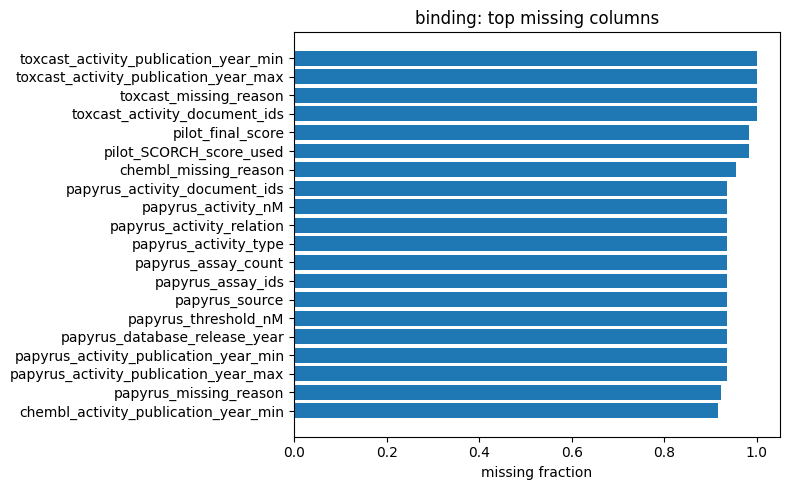

### exposure missingness


,column,missing_fraction,nonmissing
0,drug_id,0.0,498
1,target_id,0.0,498
2,upstream_source,0.0,498
3,source_family_source,0.0,498
4,source_family,0.0,498
5,target_family_source,0.0,498
6,target_family,0.0,498
7,chemical_cluster_source,0.0,498
8,chemical_cluster,0.0,498
9,consensus_score,0.0,498


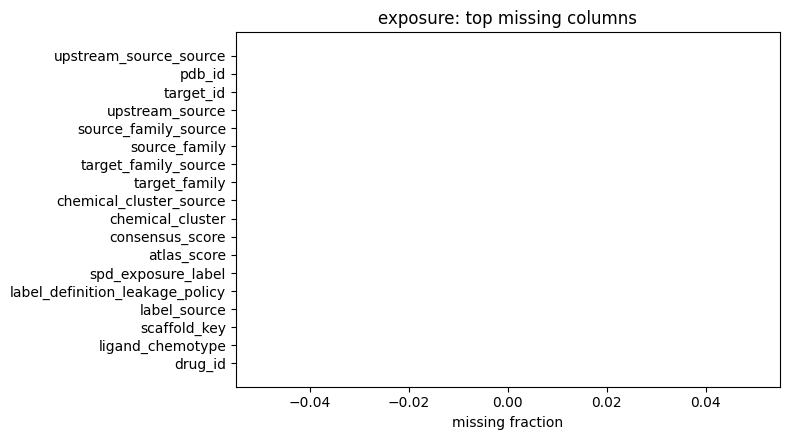

### mechanism missingness


,column,missing_fraction,nonmissing
0,toxcast_activity_publication_year_max,1.000000,0
1,toxcast_activity_publication_year_min,1.000000,0
2,toxcast_missing_reason,1.000000,0
3,toxcast_activity_document_ids,1.000000,0
4,negative_selection_features,1.000000,0
5,negative_selection_fold,1.000000,0
6,pilot_SCORCH_score_used,0.976601,19
7,pilot_final_score,0.976601,19
8,chembl_missing_reason,0.899015,82
9,papyrus_activity_type,0.839901,130


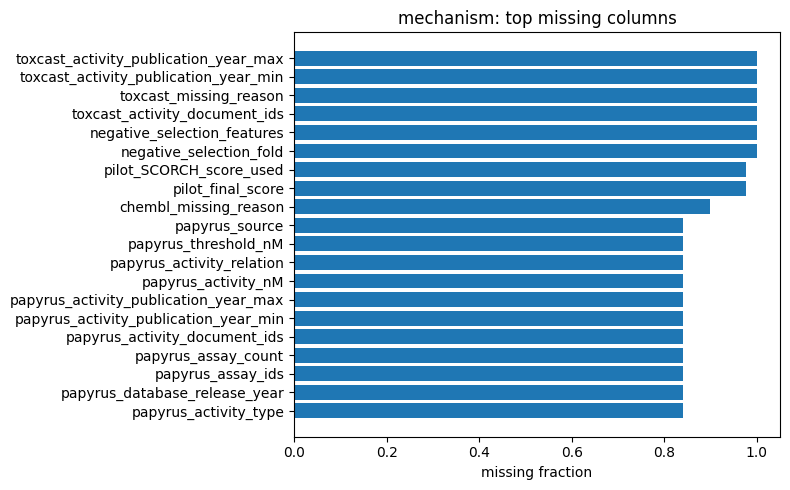

In [7]:
def missingness_report(df, top_n=25):
    miss = df.isna().mean().sort_values(ascending=False).rename('missing_fraction').reset_index()
    miss = miss.rename(columns={'index': 'column'})
    miss['nonmissing'] = len(df) - (df[miss['column']].isna().sum().to_numpy())
    return miss.head(top_n)

for name, df in tables.items():
    print('###', name, 'missingness')
    display(missingness_report(df, top_n=25))
    top = missingness_report(df, top_n=20).sort_values('missing_fraction')
    plt.figure(figsize=(8, max(3, 0.25 * len(top))))
    plt.barh(top['column'], top['missing_fraction'])
    plt.xlabel('missing fraction')
    plt.title(f'{name}: top missing columns')
    plt.tight_layout()
    plt.show()

## Label and Source Balance

In [8]:
def label_source_summary(df, label):
    out = []
    y = pd.to_numeric(df[label], errors='coerce')
    out.append(pd.DataFrame({'group': ['all'], 'n': [len(df)], 'positive_rate': [y.mean()], 'missing_label_frac': [y.isna().mean()]}))
    for col in ['label_source', 'source_family', 'upstream_source', 'target_family', 'chemical_cluster', 'ligand_chemotype']:
        if col in df.columns:
            g = df.assign(_y=y).groupby(col, dropna=False)['_y'].agg(['size', 'mean']).reset_index()
            g = g.rename(columns={col: 'group', 'size': 'n', 'mean': 'positive_rate'}).sort_values('n', ascending=False).head(12)
            g.insert(0, 'by', col)
            display(g)
    return out[0]

for name, df in tables.items():
    print('\n###', name)
    display(df[experts[name]['label']].value_counts(dropna=False).rename('count').to_frame())
    display(label_source_summary(df, experts[name]['label']))


### binding


,count
four_state_ml_label,
0.0,6187
1.0,540
NaN,291


,by,group,n,positive_rate
1,label_source,toxcast_hts,6027,0.023786
0,label_source,curated_bioactivity,991,0.555245


,by,group,n,positive_rate
1,source_family,toxcast,6027,0.023786
0,source_family,source_family_unassigned,991,0.555245


,by,group,n,positive_rate
1,upstream_source,toxcast_hts,6027,0.023786
0,upstream_source,curated_bioactivity,991,0.555245


...

,by,group,n,positive_rate
0,upstream_source,curated_bioactivity,496,0.379032
1,upstream_source,toxcast_hts,316,0.025316


,by,group,n,positive_rate
1,target_family,KINASE,285,0.094737
2,target_family,NUCLEAR_RECEPTOR,279,0.121864
0,target_family,GPCR,120,0.875000
3,target_family,OTHER_TARGET_FAMILY,114,0.219298
5,target_family,PROTEASE,8,0.625000
4,target_family,OXIDOREDUCTASE,6,0.000000


,by,group,n,positive_rate
269,chemical_cluster,chemotype:QFJCIRLUMZQUOT,12,0.0
107,chemical_cluster,chemotype:GPXBXXGIAQBQNI,11,0.0
141,chemical_cluster,chemotype:IFSDAJWBUCMOAH,11,0.0
2,chemical_cluster,chemotype:ACWZRVQXLIRSDF,11,0.0
318,chemical_cluster,chemotype:STGQPVQAAFJJFX,11,0.0
5,chemical_cluster,chemotype:AHYMHWXQRWRBKT,11,0.0
162,chemical_cluster,chemotype:JGSYRKUPDSSTCB,11,0.0
319,chemical_cluster,chemotype:STUWGJZDJHPWGZ,11,0.0
116,chemical_cluster,chemotype:GYABBVHSRIHYJR,11,0.0
32,chemical_cluster,chemotype:BSMCAPRUBJMWDF,10,0.0


,by,group,n,positive_rate
269,ligand_chemotype,QFJCIRLUMZQUOT,12,0.0
107,ligand_chemotype,GPXBXXGIAQBQNI,11,0.0
141,ligand_chemotype,IFSDAJWBUCMOAH,11,0.0
2,ligand_chemotype,ACWZRVQXLIRSDF,11,0.0
318,ligand_chemotype,STGQPVQAAFJJFX,11,0.0
5,ligand_chemotype,AHYMHWXQRWRBKT,11,0.0
162,ligand_chemotype,JGSYRKUPDSSTCB,11,0.0
319,ligand_chemotype,STUWGJZDJHPWGZ,11,0.0
116,ligand_chemotype,GYABBVHSRIHYJR,11,0.0
32,ligand_chemotype,BSMCAPRUBJMWDF,10,0.0


,group,n,positive_rate,missing_label_frac
0,all,812,0.241379,0.0


## Feature Distributions and Correlations


### binding ['consensus_score', 'banana_score', 'banana_binding_probability', 'banana_score_normalized', 'banana_atlas_blend_score', 'binding_expert_score']


,count,mean,std,min,25%,50%,75%,max
consensus_score,7018.0,0.511544,0.284740,0.000000,0.261430,0.512896,0.759429,0.999796
banana_score,7018.0,-2.271952,1.855182,-5.350031,-3.577740,-2.777430,-1.486181,4.109958
banana_binding_probability,7018.0,0.180876,0.260526,0.004726,0.027179,0.058556,0.184496,0.983856
banana_score_normalized,7018.0,0.325379,0.196108,0.000000,0.187346,0.271945,0.408441,1.000000
banana_atlas_blend_score,7018.0,0.296188,0.192523,0.071644,0.176041,0.224392,0.317626,0.940958
binding_expert_score,7018.0,0.360702,0.162923,0.115989,0.245405,0.322313,0.408517,0.945387


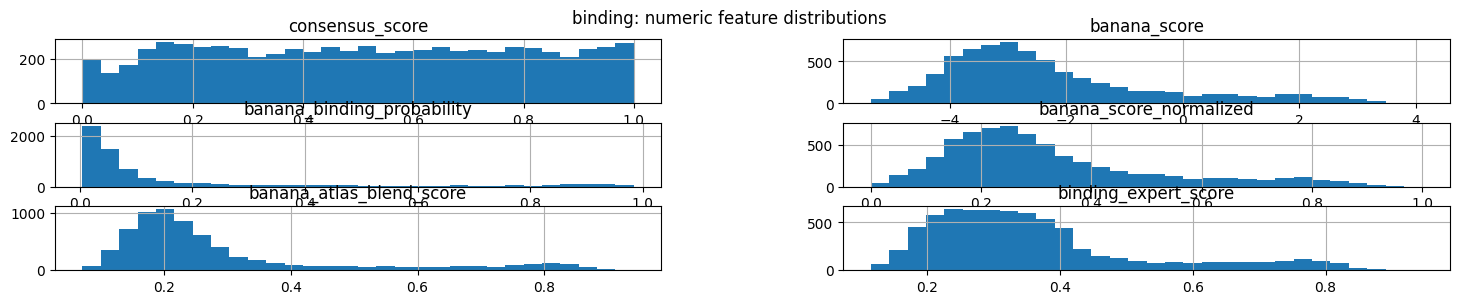

,consensus_score,banana_score,banana_binding_probability,banana_score_normalized,banana_atlas_blend_score,binding_expert_score
consensus_score,1.000,0.208,0.208,0.208,0.600,0.806
banana_score,0.208,1.000,1.000,1.000,0.865,0.665
banana_binding_probability,0.208,1.000,1.000,1.000,0.865,0.665
banana_score_normalized,0.208,1.000,1.000,1.000,0.865,0.665
banana_atlas_blend_score,0.600,0.865,0.865,0.865,1.000,0.935
binding_expert_score,0.806,0.665,0.665,0.665,0.935,1.000



### exposure ['consensus_score']


,count,mean,std,min,25%,50%,75%,max
consensus_score,498.0,0.652542,0.2751,0.0,0.475651,0.689392,0.892241,1.0


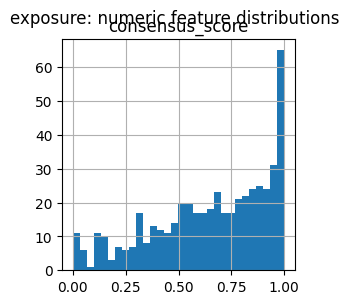


### mechanism ['atlas_score', 'consensus_score', 'banana_score', 'banana_binding_probability', 'banana_score_normalized', 'banana_atlas_blend_score', 'binding_expert_score']


,count,mean,std,min,25%,50%,75%,max
atlas_score,812.0,0.634118,0.307918,-1.758500,0.432096,0.704863,0.875121,1.734690
consensus_score,812.0,0.645988,0.282387,0.000000,0.443068,0.716179,0.888107,0.999796
banana_score,812.0,-1.160297,2.423258,-5.335635,-3.223985,-1.430683,0.947423,4.003598
banana_binding_probability,812.0,0.362028,0.355567,0.004794,0.038273,0.193026,0.720596,0.982077
banana_score_normalized,812.0,0.442890,0.256159,0.001522,0.224741,0.414308,0.665694,0.988757
banana_atlas_blend_score,812.0,0.434753,0.256913,0.071644,0.204834,0.334852,0.691658,0.913818
binding_expert_score,812.0,0.479537,0.206199,0.115989,0.308334,0.429723,0.673075,0.872476


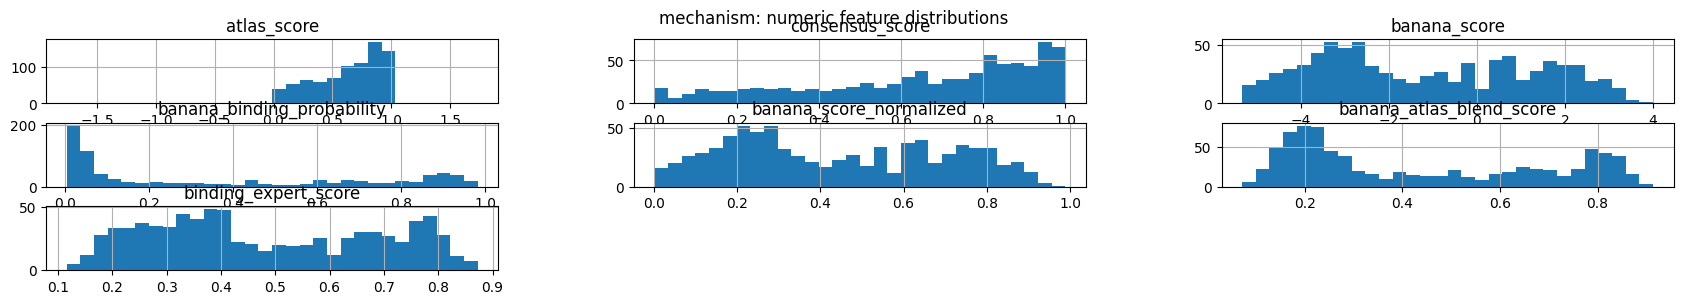

,atlas_score,consensus_score,banana_score,banana_binding_probability,banana_score_normalized,banana_atlas_blend_score,binding_expert_score
atlas_score,1.000,0.949,0.315,0.315,0.315,0.543,0.675
consensus_score,0.949,1.000,0.333,0.333,0.333,0.559,0.689
banana_score,0.315,0.333,1.000,1.000,1.000,0.951,0.882
banana_binding_probability,0.315,0.333,1.000,1.000,1.000,0.951,0.882
banana_score_normalized,0.315,0.333,1.000,1.000,1.000,0.951,0.882
banana_atlas_blend_score,0.543,0.559,0.951,0.951,0.951,1.000,0.977
binding_expert_score,0.675,0.689,0.882,0.882,0.882,0.977,1.000


In [9]:
def numeric_features(df, features):
    nums = []
    for col in features:
        if col in df.columns:
            s = pd.to_numeric(df[col], errors='coerce')
            if s.notna().any():
                nums.append(col)
    return nums

for name, df in tables.items():
    label = experts[name]['label']
    feats = experts[name]['features']
    nums = numeric_features(df, feats)
    print('\n###', name, nums)
    if nums:
        display(df[nums].describe().T)
        df[nums].hist(figsize=(3 * len(nums), 3), bins=30)
        plt.suptitle(f'{name}: numeric feature distributions')
        plt.show()
        if len(nums) > 1:
            display(df[nums].corr(method='spearman').round(3))

## Existing Metrics, Baselines, and Calibration

In [11]:
for name, cfg in experts.items():
    model_dir = Path(cfg['model_dir'])
    if not model_dir.exists():
        model_dir = RUN / name / 'model'
    print('\n###', name)
    for fname in ['model_metrics.csv', 'standard_baseline_panel.csv', 'model_grouped_calibration.csv', 'feature_importance.csv']:
        path = model_dir / fname
        if path.exists():
            print(fname)
            display(pd.read_csv(path).head(20))


### binding
model_metrics.csv


,metric,value
0,EF@1%,9.346361185983827
1,EF@5%,5.981671159029649
2,EF@10%,5.083344645038687
3,AUPRC,0.3875330153890902
4,AUROC,0.795126154389996
5,Brier,0.1505576134253071
6,ECE,0.27248584502149964
7,adaptive_ECE,0.27248584502149964
8,MCE,0.6602868771786448
9,log_loss,0.499754737189415


standard_baseline_panel.csv


,method,score_col,n,positive_rate,status,EF@1%,EF@5%,EF@10%,AUPRC,AUROC,Brier,ECE,adaptive_ECE,MCE,log_loss,precision@20_per_target_mean,hits@10_per_target_mean,recall_of_known_controls,repeat
0,atlas_score_only,atlas_score,1387,0.076424,ok,5.607817,4.486253,3.012352,0.205285,0.682552,0.313223,0.424048,0.427495,0.747322,1.009828,0.394176,2.888889,0.0,NaN
1,vina_consensus_only,consensus_score,1387,0.076424,ok,7.477089,5.047035,3.200624,0.259999,0.691566,0.306101,0.430436,0.430436,0.760063,0.881392,0.394176,2.925926,0.0,NaN
2,scorch_final_only,pilot_SCORCH_score_used,17,0.294118,ok,0.000000,0.000000,1.700000,0.471429,0.683333,0.211095,0.207926,0.199582,0.677580,0.643328,0.333333,0.416667,0.0,NaN
3,banana_bigbind_only,banana_binding_probability,1387,0.076424,ok,11.215633,6.729380,5.083345,0.416039,0.770893,0.090331,0.099758,0.112117,0.499108,0.309678,0.386769,2.703704,0.0,NaN
4,atlas_scorch_available,pilot_final_score,17,0.294118,ok,0.000000,0.000000,0.000000,0.333532,0.516667,1.161759,0.087257,0.843178,0.665611,12.385899,0.333333,0.416667,0.0,NaN
5,atlas_scorch_banana_available,banana_atlas_blend_score,1387,0.076424,ok,10.280997,6.916307,5.083345,0.408720,0.784639,0.111804,0.215942,0.215942,0.481944,0.385348,0.388620,2.814815,0.0,NaN
6,trained_model,ml_prediction_score,1387,0.076424,ok,9.346361,5.981671,5.083345,0.387533,0.795126,0.150558,0.272486,0.272486,0.660287,0.499755,0.394176,2.925926,0.0,NaN
7,random,_random_score_0,1387,0.076424,ok,2.803908,1.495418,1.129632,0.083112,0.483702,0.338383,0.440060,0.441915,0.861049,1.017387,0.362695,2.333333,0.0,0.0
8,random,_random_score_1,1387,0.076424,ok,1.869272,1.121563,1.223768,0.078243,0.469695,0.338539,0.432559,0.432124,0.862774,1.022994,0.360843,2.407407,0.0,1.0
9,random,_random_score_2,1387,0.076424,ok,1.869272,1.308491,1.317904,0.086129,0.496259,0.334964,0.433301,0.432135,0.848895,0.999946,0.362695,2.407407,0.0,2.0


model_grouped_calibration.csv


...

,method,score_col,n,positive_rate,status,EF@1%,EF@5%,EF@10%,AUPRC,AUROC,Brier,ECE,adaptive_ECE,MCE,log_loss,precision@20_per_target_mean,hits@10_per_target_mean,recall_of_known_controls,repeat
0,atlas_score_only,atlas_score,181,0.198895,ok,2.513889,1.005556,1.058480,0.251384,0.559770,0.427987,0.468258,0.469222,0.807037,1.459563,0.225,1.40,0.0,NaN
1,vina_consensus_only,consensus_score,181,0.198895,ok,2.513889,0.502778,0.793860,0.217057,0.548659,0.431872,0.470774,0.470774,0.792217,1.475054,0.225,1.36,0.0,NaN
2,scorch_final_only,pilot_SCORCH_score_used,2,0.500000,ok,2.000000,2.000000,2.000000,1.000000,1.000000,0.401305,0.479480,0.479480,0.893490,1.153614,0.500,0.50,0.0,NaN
3,banana_bigbind_only,banana_binding_probability,181,0.198895,ok,5.027778,4.525000,3.175439,0.534806,0.722989,0.203547,0.187817,0.188321,0.759930,0.618835,0.225,1.32,0.0,NaN
4,atlas_scorch_available,pilot_final_score,2,0.500000,ok,2.000000,2.000000,2.000000,1.000000,1.000000,0.115279,0.223646,0.310951,0.447292,0.296463,0.500,0.50,0.0,NaN
5,atlas_scorch_banana_available,banana_atlas_blend_score,181,0.198895,ok,5.027778,3.519444,2.910819,0.501214,0.734866,0.202153,0.217258,0.217258,0.575399,0.587977,0.225,1.32,0.0,NaN
6,trained_model,ml_prediction_score,181,0.198895,ok,5.027778,2.011111,2.116959,0.412218,0.729119,0.209268,0.249789,0.249789,0.440433,0.606371,0.225,1.36,0.0,NaN
7,random,_random_score_0,181,0.198895,ok,2.513889,1.005556,1.323099,0.230924,0.534483,0.312630,0.312543,0.315708,0.747648,0.971420,0.225,1.28,0.0,0.0
8,random,_random_score_1,181,0.198895,ok,0.000000,0.000000,0.793860,0.167743,0.399042,0.400607,0.407265,0.404416,0.781994,1.254716,0.221,1.20,0.0,1.0
9,random,_random_score_2,181,0.198895,ok,0.000000,1.508333,1.058480,0.214280,0.479885,0.318576,0.348173,0.338112,0.694861,0.952240,0.221,1.16,0.0,2.0


model_grouped_calibration.csv


,group_col,group_value,n,positive_rate,EF@1%,EF@5%,EF@10%,AUPRC,AUROC,Brier,ECE,adaptive_ECE,MCE,log_loss
0,label_source,curated_bioactivity,125,0.280000,3.571429,2.040816,1.648352,0.424287,0.619048,0.259586,0.246061,0.238262,0.440433,0.716487
1,label_source,toxcast_hts,56,0.017857,0.000000,18.666667,9.333333,0.500000,0.981818,0.096952,0.276287,0.276287,0.641944,0.360575
2,source_family,source_family_unassigned,125,0.280000,3.571429,2.040816,1.648352,0.424287,0.619048,0.259586,0.246061,0.238262,0.440433,0.716487
3,source_family,toxcast,56,0.017857,0.000000,18.666667,9.333333,0.500000,0.981818,0.096952,0.276287,0.276287,0.641944,0.360575
4,chemical_cluster,chemotype:AAZXOZJBHDWFHY,1,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,chemical_cluster,chemotype:AHYMHWXQRWRBKT,11,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,chemical_cluster,chemotype:AWMFUEJKWXESNL,1,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,chemical_cluster,chemotype:BFPYWIDHMRZLRN,2,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,chemical_cluster,chemotype:BGEBZHIAGXMEMV,1,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,chemical_cluster,chemotype:BJIOGJUNALELMI,1,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


feature_importance.csv


,feature,importance
0,atlas_score,2.293259
1,banana_binding_probability,1.431915
2,consensus_score,-1.214082
3,banana_score_normalized,-0.553722
4,banana_atlas_blend_score,0.528138
5,binding_expert_score,0.217372
6,banana_score,0.080773


## Feature-Set Editor

Use this as the main scratchpad for feature experiments. It starts from the current selected features, then you can add/drop columns safely. The custom runner below blocks raw IDs.

In [ ]:
BASE_FEATURES = {name: cfg['features'][:] for name, cfg in experts.items()}

CANDIDATE_FEATURES = {
    'binding': ['consensus_score', 'banana_binding_probability'],
    'exposure': ['consensus_score', 'ligand_chemotype', 'scaffold_key'],
    'mechanism': ['atlas_score', 'consensus_score', 'banana_binding_probability'],
}

def available_features(expert):
    df = tables[expert]
    return sorted([c for c in df.columns if c not in {'drug_id', 'target_id', 'pdb_id'}])

def validate_candidate_features(expert, features):
    forbidden = {'drug_id', 'target_id', 'pdb_id', 'literature_supported_label'}
    missing = [f for f in features if f not in tables[expert].columns]
    bad = sorted(set(features) & forbidden)
    return {'expert': expert, 'features': features, 'missing': missing, 'forbidden': bad}

validate_candidate_features(ACTIVE_EXPERT, CANDIDATE_FEATURES[ACTIVE_EXPERT])

## Notebook-Side Model Comparison

This trains several common model families on the same split manifest. It is exploratory only; the repo training pipeline remains the source of truth for publication outputs.

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, roc_auc_score, brier_score_loss, log_loss
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import SVC

def metric_row(y, p):
    y = np.asarray(y).astype(int)
    p = np.asarray(p).astype(float)
    return {
        'AUROC': roc_auc_score(y, p) if len(set(y)) == 2 else np.nan,
        'AUPRC': average_precision_score(y, p) if len(set(y)) == 2 else np.nan,
        'Brier': brier_score_loss(y, p),
        'log_loss': log_loss(y, np.clip(p, 1e-6, 1 - 1e-6), labels=[0, 1]),
    }

def dense_one_hot_encoder():
    try:
        return OneHotEncoder(handle_unknown='ignore', sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown='ignore', sparse=False)

def build_preprocessor(x):
    num_cols = [c for c in x.columns if pd.api.types.is_numeric_dtype(x[c])]
    cat_cols = [c for c in x.columns if c not in num_cols]
    return ColumnTransformer([
        ('num', Pipeline([('impute', SimpleImputer(strategy='median')), ('scale', StandardScaler())]), num_cols),
        ('cat', Pipeline([('impute', SimpleImputer(strategy='most_frequent')), ('onehot', dense_one_hot_encoder())]), cat_cols),
    ])

models = {
    'logistic_regression': LogisticRegression(max_iter=1000, class_weight='balanced'),
    'random_forest': RandomForestClassifier(n_estimators=300, random_state=42, class_weight='balanced'),
    'hist_gradient_boosting': HistGradientBoostingClassifier(random_state=42),
    'svm_rbf': SVC(probability=True, class_weight='balanced', random_state=42),
    'knn': KNeighborsClassifier(n_neighbors=15),
}

rows = []
for name, cfg in experts.items():
    df = tables[name].copy()
    label = cfg['label']
    features = [f for f in cfg['features'] if f in df.columns]
    y_all = pd.to_numeric(df[label], errors='coerce')
    observed = y_all.notna()
    df = df.loc[observed].copy()
    df[label] = y_all.loc[observed].astype(int)
    model_dir = Path(cfg['model_dir'])
    if not model_dir.exists():
        model_dir = RUN / name / 'model'
    split = pd.read_csv(model_dir / 'split_manifest.csv')
    train_idx = split.loc[split['split'].eq('train'), '_row_index'].astype(int)
    test_idx = split.loc[split['split'].eq('test'), '_row_index'].astype(int)
    train_idx = [i for i in train_idx if i in df.index]
    test_idx = [i for i in test_idx if i in df.index]
    x_train, y_train = df.loc[train_idx, features], df.loc[train_idx, label]
    x_test, y_test = df.loc[test_idx, features], df.loc[test_idx, label]
    pre = build_preprocessor(x_train)
    for model_name, model in models.items():
        pipe = Pipeline([('preprocess', pre), ('model', model)])
        pipe.fit(x_train, y_train)
        if hasattr(pipe.named_steps['model'], 'predict_proba'):
            p = pipe.predict_proba(x_test)[:, 1]
        else:
            p = pipe.decision_function(x_test)
        rows.append({'expert': name, 'model': model_name, 'n_train': len(x_train), 'n_test': len(x_test), **metric_row(y_test, p)})

comparison = pd.DataFrame(rows).sort_values(['expert', 'AUPRC'], ascending=[True, False])
comparison

## Alternate Holdout Experiments

Drug holdout is not enough. These cells rerun quick notebook-side model comparisons under target and chemical-cluster holdouts. This is exploratory; use the CLI audit suite for publication outputs.

In [12]:
from analysis.ml.splits import make_split, split_overlap_summary

def quick_holdout_experiment(expert, feature_list, model_name='logistic_regression', split_mode='target_holdout', seed=42):
    forbidden = {'drug_id', 'target_id', 'pdb_id', 'literature_supported_label'}
    bad = sorted(set(feature_list) & forbidden)
    if bad:
        raise ValueError(f'Forbidden ID/leakage features requested: {bad}')
    df = tables[expert].copy()
    label = experts[expert]['label']
    feature_list = [f for f in feature_list if f in df.columns]
    y_all = pd.to_numeric(df[label], errors='coerce')
    df = df.loc[y_all.notna()].copy()
    df[label] = y_all.loc[y_all.notna()].astype(int)
    train_idx, test_idx = make_split(df, split_mode=split_mode, seed=seed)
    train, test = df.loc[train_idx], df.loc[test_idx]
    if train[label].nunique() < 2 or test[label].nunique() < 2:
        return {'expert': expert, 'model': model_name, 'split': split_mode, 'status': 'skipped_one_class', 'n_train': len(train), 'n_test': len(test)}
    x_train, y_train = train[feature_list], train[label]
    x_test, y_test = test[feature_list], test[label]
    pipe = Pipeline([('preprocess', build_preprocessor(x_train)), ('model', models[model_name])])
    pipe.fit(x_train, y_train)
    p = pipe.predict_proba(x_test)[:, 1]
    return {
        'expert': expert, 'model': model_name, 'split': split_mode, 'status': 'ok',
        'features': ';'.join(feature_list), 'n_train': len(train), 'n_test': len(test),
        **metric_row(y_test, p),
        'overlap': split_overlap_summary(train, test, split_mode).get('overlaps', {}),
    }

def compare_holdouts(expert, feature_list=None, model_names=('logistic_regression', 'random_forest'), split_modes=('drug_holdout', 'target_holdout', 'chemical_cluster_holdout')):
    feature_list = feature_list or experts[expert]['features']
    rows = []
    for split_mode in split_modes:
        for model_name in model_names:
            try:
                rows.append(quick_holdout_experiment(expert, feature_list, model_name=model_name, split_mode=split_mode))
            except Exception as exc:
                rows.append({'expert': expert, 'model': model_name, 'split': split_mode, 'status': 'failed', 'error': str(exc)})
    return pd.DataFrame(rows)

holdout_comparison = compare_holdouts(ACTIVE_EXPERT, CANDIDATE_FEATURES.get(ACTIVE_EXPERT))
holdout_comparison

ModuleNotFoundError: No module named 'analysis'

## Split Checks

This checks the model's current primary split manifest. Current defaults use drug holdout. For publication, rerun and compare target/chemical-cluster/source holdouts as well.

In [ ]:
for name, cfg in experts.items():
    model_dir = Path(cfg['model_dir'])
    if not model_dir.exists():
        model_dir = RUN / name / 'model'
    split_path = model_dir / 'split_manifest.csv'
    print('\n###', name, split_path)
    split = pd.read_csv(split_path)
    display(split['split'].value_counts().to_frame('rows'))
    label = cfg['label']
    if label in split.columns:
        display(split.groupby('split')[label].agg(['size', 'mean']))
    for field in ['drug_id', 'target_id', 'scaffold_key', 'chemical_cluster', 'target_family']:
        if field in split.columns:
            train_vals = set(split.loc[split['split'].eq('train'), field].dropna().astype(str))
            test_vals = set(split.loc[split['split'].eq('test'), field].dropna().astype(str))
            print(field, 'overlap=', len(train_vals & test_vals), 'train_unique=', len(train_vals), 'test_unique=', len(test_vals))

## Prediction Diagnostics

For imbalanced biological labels, inspect ROC, precision-recall, calibration, score distributions, and confusion matrices together. AUROC alone can look acceptable while precision at useful thresholds is poor.

In [ ]:
from sklearn.calibration import calibration_curve
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay,
    precision_score, recall_score, f1_score, balanced_accuracy_score
)

def load_predictions(expert):
    model_dir = Path(experts[expert]['model_dir'])
    if not model_dir.exists():
        model_dir = RUN / expert / 'model'
    pred = pd.read_csv(model_dir / 'model_predictions.csv')
    label = experts[expert]['label']
    pred = pred[pred[label].notna()].copy()
    pred[label] = pred[label].astype(int)
    return pred, label

def threshold_table(y, p, thresholds=(0.1, 0.2, 0.5, 0.8, 0.9)):
    rows = []
    for t in thresholds:
        yp = (p >= t).astype(int)
        rows.append({
            'threshold': t,
            'predicted_positive': int(yp.sum()),
            'precision': precision_score(y, yp, zero_division=0),
            'recall': recall_score(y, yp, zero_division=0),
            'f1': f1_score(y, yp, zero_division=0),
            'balanced_accuracy': balanced_accuracy_score(y, yp),
        })
    return pd.DataFrame(rows)

def topk_table(y, p, ks=(10, 20, 50, 100)):
    order = np.argsort(-np.asarray(p))
    rows = []
    base_rate = float(np.mean(y)) if len(y) else np.nan
    for k in ks:
        kk = min(k, len(order))
        if kk == 0:
            continue
        selected = np.asarray(y)[order[:kk]]
        precision = float(np.mean(selected))
        rows.append({'top_k': kk, 'hits': int(selected.sum()), 'precision_at_k': precision, 'enrichment_vs_base_rate': precision / base_rate if base_rate else np.nan})
    return pd.DataFrame(rows)

def plot_prediction_diagnostics(expert):
    pred, label = load_predictions(expert)
    y = pred[label].astype(int).to_numpy()
    p = pred['ml_prediction_score'].astype(float).to_numpy()
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    RocCurveDisplay.from_predictions(y, p, ax=axes[0, 0])
    PrecisionRecallDisplay.from_predictions(y, p, ax=axes[0, 1])
    frac_pos, mean_pred = calibration_curve(y, p, n_bins=8, strategy='quantile')
    axes[0, 2].plot(mean_pred, frac_pos, marker='o')
    axes[0, 2].plot([0, 1], [0, 1], linestyle='--', color='gray')
    axes[0, 2].set_title('Calibration')
    axes[0, 2].set_xlabel('mean predicted probability')
    axes[0, 2].set_ylabel('observed positive rate')
    axes[1, 0].hist(p[y == 0], bins=25, alpha=0.6, label='negative')
    axes[1, 0].hist(p[y == 1], bins=25, alpha=0.6, label='positive')
    axes[1, 0].set_title('Prediction score distribution')
    axes[1, 0].legend()
    cm = confusion_matrix(y, (p >= 0.5).astype(int), labels=[0, 1])
    ConfusionMatrixDisplay(cm, display_labels=[0, 1]).plot(ax=axes[1, 1], colorbar=False)
    axes[1, 1].set_title('Confusion matrix @ 0.5')
    axes[1, 2].axis('off')
    fig.suptitle(expert)
    plt.tight_layout()
    plt.show()
    display(threshold_table(y, p))
    display(topk_table(y, p))

for expert in experts:
    plot_prediction_diagnostics(expert)

## Error Analysis Tables

Inspect false positives, false negatives, worst targets, worst drugs, and top unsupported predictions. These tables are often the fastest way to find mapping or source-label problems.

In [ ]:
def error_tables(expert, threshold=0.5, top_n=25):
    pred, label = load_predictions(expert)
    pred = pred.copy()
    pred['predicted_label'] = (pred['ml_prediction_score'] >= threshold).astype(int)
    pred['error_type'] = np.select(
        [pred[label].eq(1) & pred['predicted_label'].eq(0), pred[label].eq(0) & pred['predicted_label'].eq(1)],
        ['false_negative', 'false_positive'],
        default='correct'
    )
    cols = [c for c in ['drug_id', 'target_id', 'pdb_id', 'ligand_chemotype', 'label_source', 'source_family', 'target_family', 'chemical_cluster', label, 'ml_prediction_score', 'error_type'] if c in pred.columns]
    false_pos = pred[pred['error_type'].eq('false_positive')].sort_values('ml_prediction_score', ascending=False)[cols].head(top_n)
    false_neg = pred[pred['error_type'].eq('false_negative')].sort_values('ml_prediction_score', ascending=True)[cols].head(top_n)
    groups = {}
    for group_col in ['target_id', 'drug_id', 'pdb_id', 'target_family', 'chemical_cluster', 'label_source']:
        if group_col in pred.columns:
            g = pred.assign(is_error=pred['error_type'].ne('correct')).groupby(group_col).agg(
                n=(label, 'size'),
                positive_rate=(label, 'mean'),
                mean_prediction=('ml_prediction_score', 'mean'),
                error_rate=('is_error', 'mean'),
            ).reset_index().sort_values(['error_rate', 'n'], ascending=[False, False]).head(top_n)
            groups[group_col] = g
    return false_pos, false_neg, groups

for expert in experts:
    print('###', expert)
    fp, fn, groups = error_tables(expert)
    print('False positives')
    display(fp)
    print('False negatives')
    display(fn)
    for group, table in groups.items():
        print('Worst by', group)
        display(table.head(10))

## Safe Export Helpers

Notebook outputs go under `notebooks/outputs/` by default. These helpers avoid overwriting pipeline outputs.

In [ ]:
from datetime import datetime

NOTEBOOK_OUT = REPO / 'notebooks' / 'outputs'
NOTEBOOK_OUT.mkdir(parents=True, exist_ok=True)

def timestamp_tag():
    return datetime.now().strftime('%Y%m%d_%H%M%S')

def safe_export_df(df, name, subdir='experiments'):
    out_dir = NOTEBOOK_OUT / subdir
    out_dir.mkdir(parents=True, exist_ok=True)
    path = out_dir / f'{timestamp_tag()}_{name}.csv'
    df.to_csv(path, index=False)
    print('wrote', path)
    return path

def safe_export_json(obj, name, subdir='experiments'):
    out_dir = NOTEBOOK_OUT / subdir
    out_dir.mkdir(parents=True, exist_ok=True)
    path = out_dir / f'{timestamp_tag()}_{name}.json'
    path.write_text(json.dumps(obj, indent=2, sort_keys=True), encoding='utf-8')
    print('wrote', path)
    return path

NOTEBOOK_OUT

## Feature Importance Comparison

Compare saved pipeline feature importance with quick permutation importance from a notebook-side model. This helps identify whether one score column dominates.

In [ ]:
from sklearn.inspection import permutation_importance

def saved_feature_importance(expert):
    model_dir = Path(experts[expert]['model_dir'])
    if not model_dir.exists():
        model_dir = RUN / expert / 'model'
    path = model_dir / 'feature_importance.csv'
    if path.exists():
        return pd.read_csv(path)
    return pd.DataFrame()

def permutation_importance_table(expert, feature_list=None, model_name='random_forest', n_repeats=5):
    df = tables[expert].copy()
    label = experts[expert]['label']
    feature_list = feature_list or experts[expert]['features']
    y_all = pd.to_numeric(df[label], errors='coerce')
    df = df.loc[y_all.notna()].copy()
    df[label] = y_all.loc[y_all.notna()].astype(int)
    model_dir = Path(experts[expert]['model_dir'])
    if not model_dir.exists():
        model_dir = RUN / expert / 'model'
    split = pd.read_csv(model_dir / 'split_manifest.csv')
    train_idx = [i for i in split.loc[split['split'].eq('train'), '_row_index'].astype(int) if i in df.index]
    test_idx = [i for i in split.loc[split['split'].eq('test'), '_row_index'].astype(int) if i in df.index]
    x_train, y_train = df.loc[train_idx, feature_list], df.loc[train_idx, label]
    x_test, y_test = df.loc[test_idx, feature_list], df.loc[test_idx, label]
    pipe = Pipeline([('preprocess', build_preprocessor(x_train)), ('model', models[model_name])])
    pipe.fit(x_train, y_train)
    result = permutation_importance(pipe, x_test, y_test, scoring='average_precision', n_repeats=n_repeats, random_state=42)
    return pd.DataFrame({'feature': feature_list, 'importance_mean': result.importances_mean, 'importance_std': result.importances_std}).sort_values('importance_mean', ascending=False)

for expert in experts:
    print('###', expert, 'saved importance')
    display(saved_feature_importance(expert).head(20))
    print('###', expert, 'permutation importance')
    display(permutation_importance_table(expert, n_repeats=3).head(20))

## Custom Feature Experiment Sandbox

Use this cell for fast iterations. It uses the same split manifest as the saved pipeline run, blocks raw ID features, and returns metrics without writing new pipeline artifacts.

In [ ]:
def run_custom_experiment(expert, feature_list, model_name='logistic_regression'):
    forbidden = {'drug_id', 'target_id', 'pdb_id', 'literature_supported_label'}
    bad = sorted(set(feature_list) & forbidden)
    if bad:
        raise ValueError(f'Forbidden ID/leakage features requested: {bad}')
    df = tables[expert].copy()
    label = experts[expert]['label']
    feature_list = [f for f in feature_list if f in df.columns]
    if not feature_list:
        raise ValueError('No requested features are present in the table')
    y_all = pd.to_numeric(df[label], errors='coerce')
    observed = y_all.notna()
    df = df.loc[observed].copy()
    df[label] = y_all.loc[observed].astype(int)
    model_dir = Path(experts[expert]['model_dir'])
    if not model_dir.exists():
        model_dir = RUN / expert / 'model'
    split = pd.read_csv(model_dir / 'split_manifest.csv')
    train_idx = [i for i in split.loc[split['split'].eq('train'), '_row_index'].astype(int) if i in df.index]
    test_idx = [i for i in split.loc[split['split'].eq('test'), '_row_index'].astype(int) if i in df.index]
    x_train, y_train = df.loc[train_idx, feature_list], df.loc[train_idx, label]
    x_test, y_test = df.loc[test_idx, feature_list], df.loc[test_idx, label]
    model = models[model_name]
    pipe = Pipeline([('preprocess', build_preprocessor(x_train)), ('model', model)])
    pipe.fit(x_train, y_train)
    p = pipe.predict_proba(x_test)[:, 1]
    return {
        'expert': expert,
        'model': model_name,
        'features': ';'.join(feature_list),
        'n_train': len(x_train),
        'n_test': len(x_test),
        **metric_row(y_test, p),
    }

# Example: compare two binding feature ideas on the same held-out drugs.
custom_results = pd.DataFrame([
    run_custom_experiment('binding', ['consensus_score', 'banana_binding_probability'], 'logistic_regression'),
    run_custom_experiment('binding', ['consensus_score', 'banana_binding_probability'], 'random_forest'),
])
custom_results

## Quick Experiment Log

Use this table to keep notebook experiments auditable. Add rows when you try a new feature subset, model family, split, or threshold policy. If an experiment is worth keeping, move it into the real pipeline code and rerun from the CLI.

In [ ]:
experiment_log = pd.DataFrame([
    {
        'date': pd.Timestamp.today().date().isoformat(),
        'expert': 'binding',
        'question': 'Does a non-linear model beat logistic regression on the same drug holdout?',
        'data': str(experts['binding']['dataset']),
        'split': 'existing split_manifest.csv',
        'decision': 'exploratory notebook only until reproduced in CLI',
    }
])
experiment_log

## Promote-to-Pipeline Summary

When a notebook experiment looks useful, generate this compact summary. Hand it to Codex or use it to update `analysis/ml/feature_sets.py` and the relevant CLI defaults.

In [ ]:
PROMOTE = {
    'expert': ACTIVE_EXPERT,
    'label': experts[ACTIVE_EXPERT]['label'],
    'candidate_feature_set_name': f'{ACTIVE_EXPERT}_notebook_candidate',
    'features': CANDIDATE_FEATURES.get(ACTIVE_EXPERT, experts[ACTIVE_EXPERT]['features']),
    'model_candidates': list(models.keys()),
    'recommended_splits_to_report': ['drug_holdout', 'target_holdout', 'chemical_cluster_holdout'],
    'source_run': str(RUN),
    'notes': 'Exploratory notebook result; promote only after reproducing through CLI training/audit.',
}
print(json.dumps(PROMOTE, indent=2))
# Optional safe export:
# safe_export_json(PROMOTE, 'promote_to_pipeline_summary')

## Next Checks to Add After Full SPD Run

- Repeat the model comparison under `target_holdout`, `chemical_cluster_holdout`, and `target_family_holdout`.
- Add MM/GBSA as a standalone feature set/ablation when available.
- Compare full-library features separately from SCORCH-rescored-subset features.


## Run-Scoped ML Manifests

Use this section after `atlas ml train`, `atlas ml hpo`, Chemprop/TDC staging, or generated-molecule benchmark capture. It reads manifests only; it does not import or launch optional third-party ML tools.


In [ ]:
from analysis.ml.notebook_summary import display_ml_run_summary

RUN_ID = 'pilotstudy'
ml_summary = display_ml_run_summary(RUN_ID, repo_root=REPO_ROOT)
ml_summary.drop(columns=['manifest'], errors='ignore').head(20)
